In [1]:
# Define functions for audio processing and mixing

from pathlib import Path
import numpy as np
import soundfile as sf
import librosa
import matplotlib.pyplot as plt
from scipy.signal import welch
from dataset import gt_conversion_functions as gt_conv
import importlib


def most_powerful_band(x, sr, bands=None, nperseg=4096, noverlap=None, averaging="mean"):
    """
    x: np.ndarray, shape (T,) or (C, T)
    sr: sampling rate (Hz)
    bands: list of (f_low, f_high) in Hz. If None -> 10 log-spaced bands.
    averaging: "mean" or "sum" power within band
    """
    x = np.asarray(x)
    if x.ndim == 1:
        x = x[None, :]  # -> (1, T)
    C, T = x.shape

    # PSD per channel
    f, Pxx = welch(x, fs=sr, axis=-1, nperseg=nperseg, noverlap=noverlap)  # shape: (C, F)

    # default: 10 log-spaced bands from 20 Hz to Nyquist
    if bands is None:
        fmin, fmax = max(20, f[1]), f[-1]
        edges = np.geomspace(fmin, fmax, 11)  # 10 bands
        bands = list(zip(edges[:-1], edges[1:]))

    band_powers = []
    for (fl, fh) in bands:
        m = (f >= fl) & (f < fh)
        if not np.any(m):
            band_powers.append(np.zeros(C))
            continue
        band_power = Pxx[:, m].mean(axis=1) if averaging == "mean" else Pxx[:, m].sum(axis=1)
        band_powers.append(band_power)

    band_powers = np.stack(band_powers, axis=0)  # (B, C)
    # pick band with max power per channel
    idx_max = band_powers.argmax(axis=0)         # (C,)
    best_bands = [bands[i] for i in idx_max]
    best_vals  = band_powers[idx_max, range(C)]

    # also report single peak frequency per channel
    peak_idx = Pxx.argmax(axis=1)
    peak_freqs = f[peak_idx]

    return {
        "bands": bands,
        "band_powers": band_powers,   # (B, C)
        "best_band_per_channel": best_bands,
        "best_band_power": best_vals,
        "peak_freq_per_channel": peak_freqs
    }


def load_mono(path, sr=None, offset=None, duration=None):
    y, sr = librosa.load(path, sr=sr, mono=True, offset=offset, duration=duration)  # to mono, optional resample
    return y, sr

def set_length(a, length= None):
    if length != None:
        while len(a) < length:
            a = np.concatenate((a, a))
        # if length < len(a):
        #     L = min(len(a), len(b))
        # else:
        #     raise ValueError("Unexpected length comparison.")
        
        return a[:length]
    else:
        raise ValueError("mode must be 'min' or 'max'")

def normalize_peak(y, peak=0.99):
    m = np.max(np.abs(y))
    return y if m == 0 else y * (peak / m)

def mix_signals(
    s, w, sr,
    A=None,                 # None, (2,), or (5,2) weights: x[i] = A[i,0]*s[i] + A[i,1]*w[i]
    snr=None,
    length_mode="min",      # how to align each row-pair
    add_noise_std=0.0,      # Gaussian noise std (linear)
    peak=0.99,              # peak normalize target
    out_dir=None,           # optional folder to write mix_1..5.wav
    subtype="PCM_16"        # WAV subtype for soundfile
):
    """
    Mix 5 row-pairs from s and w into 5 mixtures, one per row.

    Args:
        s, w: np.ndarray shaped (5, T_i). Each row is a mono signal (float).
        sr: sample rate (int), used if saving WAVs.
        A: None -> equal weights (1/sqrt(2), 1/sqrt(2)).
           (2,) -> same weights for all rows, e.g., [0.8, 0.6].
           (5,2) -> per-row weights.
        length_mode: 'min' (trim) or 'max' (pad with zeros) per row.
        add_noise_std: additive white noise std (after mixing, before normalization).
        peak: target peak amplitude after normalization.
        out_dir: if provided, saves mix_i.wav files.
        subtype: WAV subtype for saving (e.g., 'PCM_16', 'FLOAT').

    Returns:
        x: np.ndarray, shape (5, T), mixtures.
        paths: list of written file paths (or []).
    """
    s = np.asarray(s, dtype=np.float32)
    w = np.asarray(w, dtype=np.float32)

    if s.ndim != 2 or w.ndim != 2 or s.shape[0] != 5 or w.shape[0] != 5:
        raise ValueError("s and w must be shape (5, T).")

    # Handle A
    if A is None:
        A = np.array([1/np.sqrt(2), 1/np.sqrt(2)], dtype=np.float32)  # equal-energy
    A = np.asarray(A, dtype=np.float32)
    if A.shape == (2,):
        A = np.tile(A, (5, 1))  # same weights for all rows
    if A.shape != (5, 2):
        raise ValueError("A must be None, shape (2,), or shape (5,2).")

    # Mix row-by-row
    mixes = []
    for i in range(5):
        si, wi = s[i], w[i]
        # si, wi = make_same_length(si, wi, mode=length_mode)
        xi = A[i, 0] * si + A[i, 1] * wi
        if add_noise_std > 0:
            xi = xi + np.random.randn(*xi.shape).astype(np.float32) * add_noise_std
        xi = normalize_peak(xi, peak=peak)
        mixes.append(xi.astype(np.float32))

    # Stack to (5, T)
    max_len = max(len(xi) for xi in mixes)
    X = np.zeros((5, max_len), dtype=np.float32)
    for i, xi in enumerate(mixes):
        X[i, :len(xi)] = xi  # pad with zeros if lengths differ

    # Optional saving
    paths = []
    if out_dir is not None:
        out = Path(out_dir)
        out.mkdir(parents=True, exist_ok=True)
        for i in range(5):
            p = out / f"snr{snr}_mix_{i+1}.wav"
            sf.write(p.as_posix(), X[i], sr, subtype=subtype)
            paths.append(p.as_posix())

    return X, paths

def plot_fft(signals, sr, title_prefix, titles=""):
    n = signals.shape[0]
    freq = np.fft.rfftfreq(n, d=1/sr)
    plt.figure(figsize=(14, 8))
    for i in range(signals.shape[1]):
        fft_vals = np.fft.rfft(signals[:, i])
        plt.subplot(signals.shape[1], 1, i+1)
        plt.plot(freq, np.abs(fft_vals))
        plt.title(f"{title_prefix} {i+1} {titles[i]} - Magnitude Spectrum")
        plt.xlabel("Frequency [Hz]")
        plt.ylabel("Magnitude")
    plt.tight_layout()
    plt.show()

def plot_waveforms(signals, sr, title_prefix):
    time = np.arange(signals.shape[0]) / sr
    plt.figure(figsize=(14, 8))
    for i in range(signals.shape[1]):
        plt.subplot(signals.shape[1], 1, i+1)
        plt.plot(time, signals[:, i])
        plt.title(f"{title_prefix} {i+1} - Waveform")
        plt.xlabel("Time [s]")
        plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()



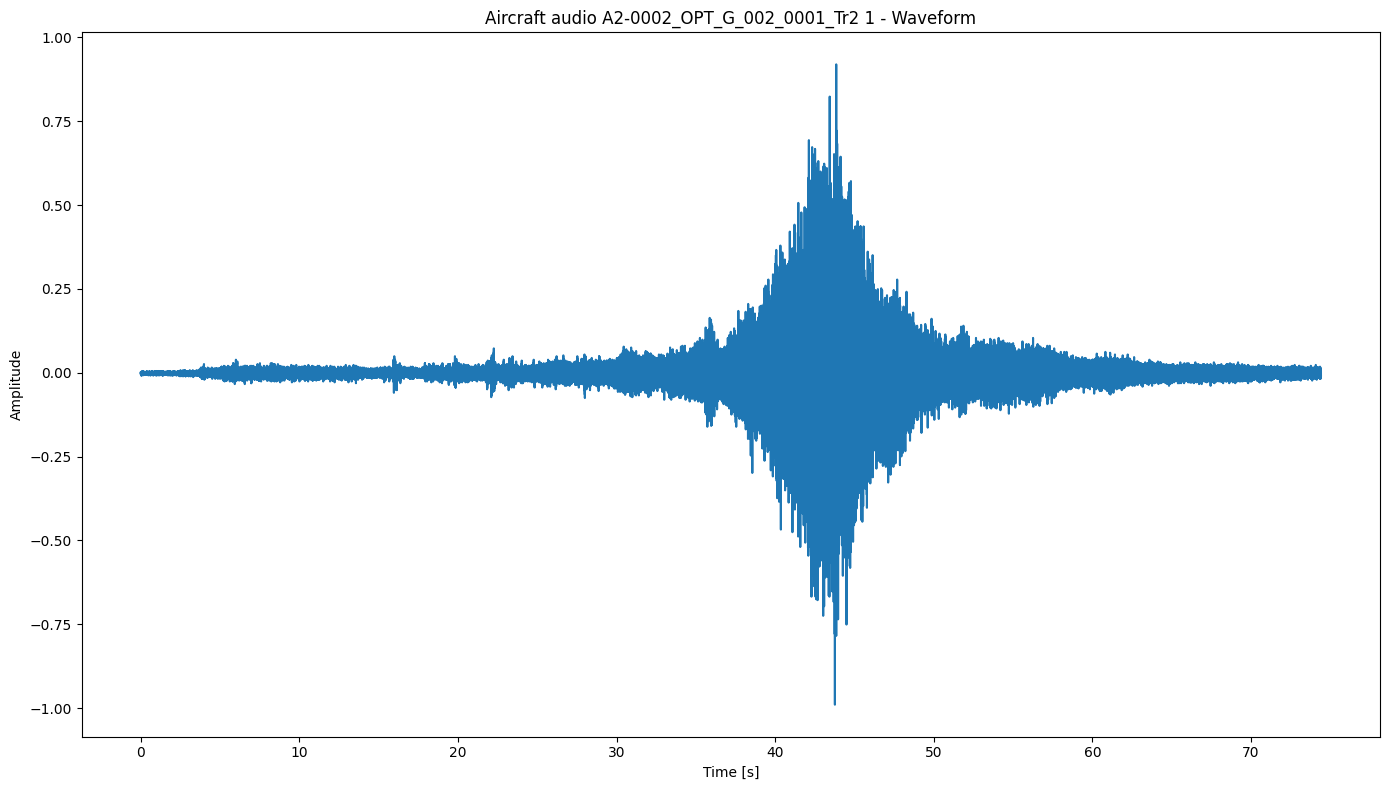

Loaded 1 aircraft files.


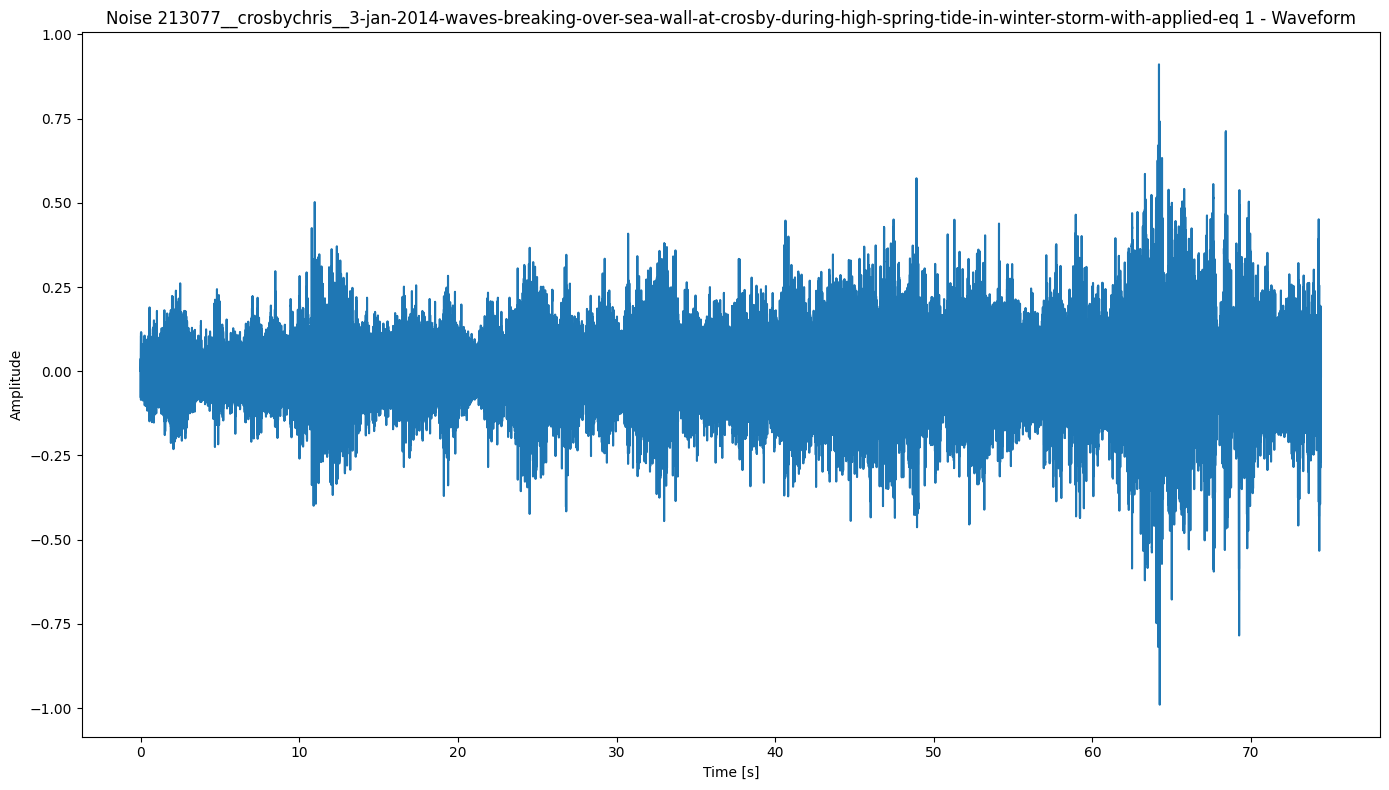

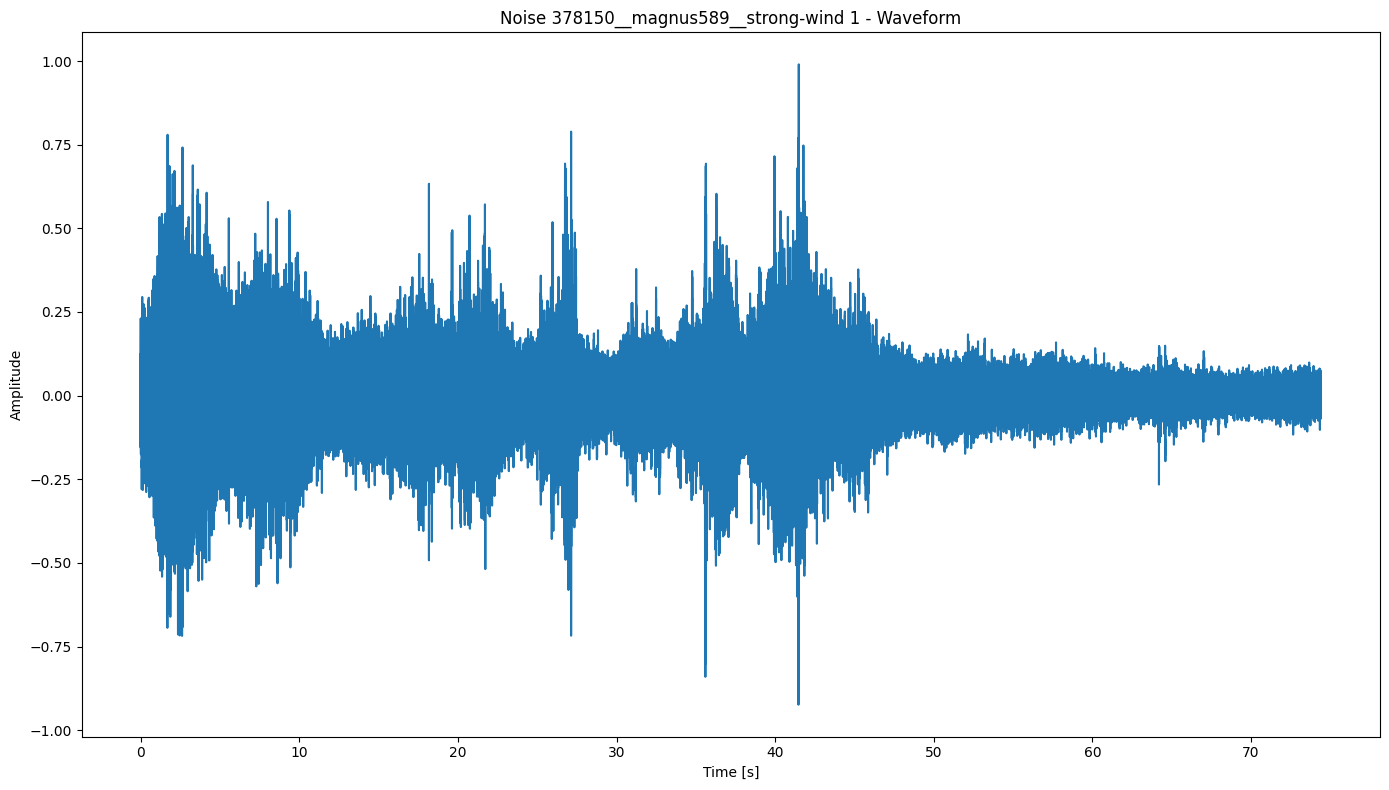

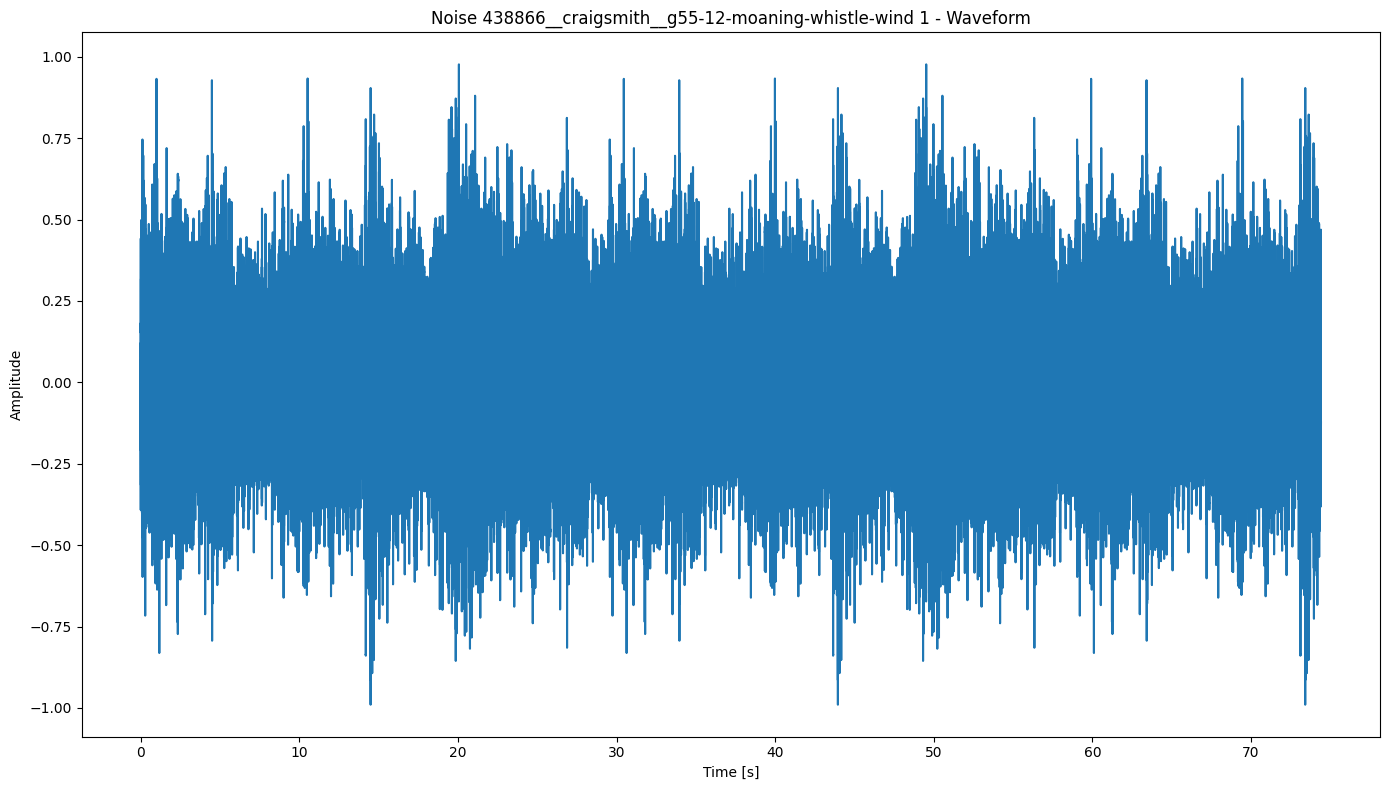

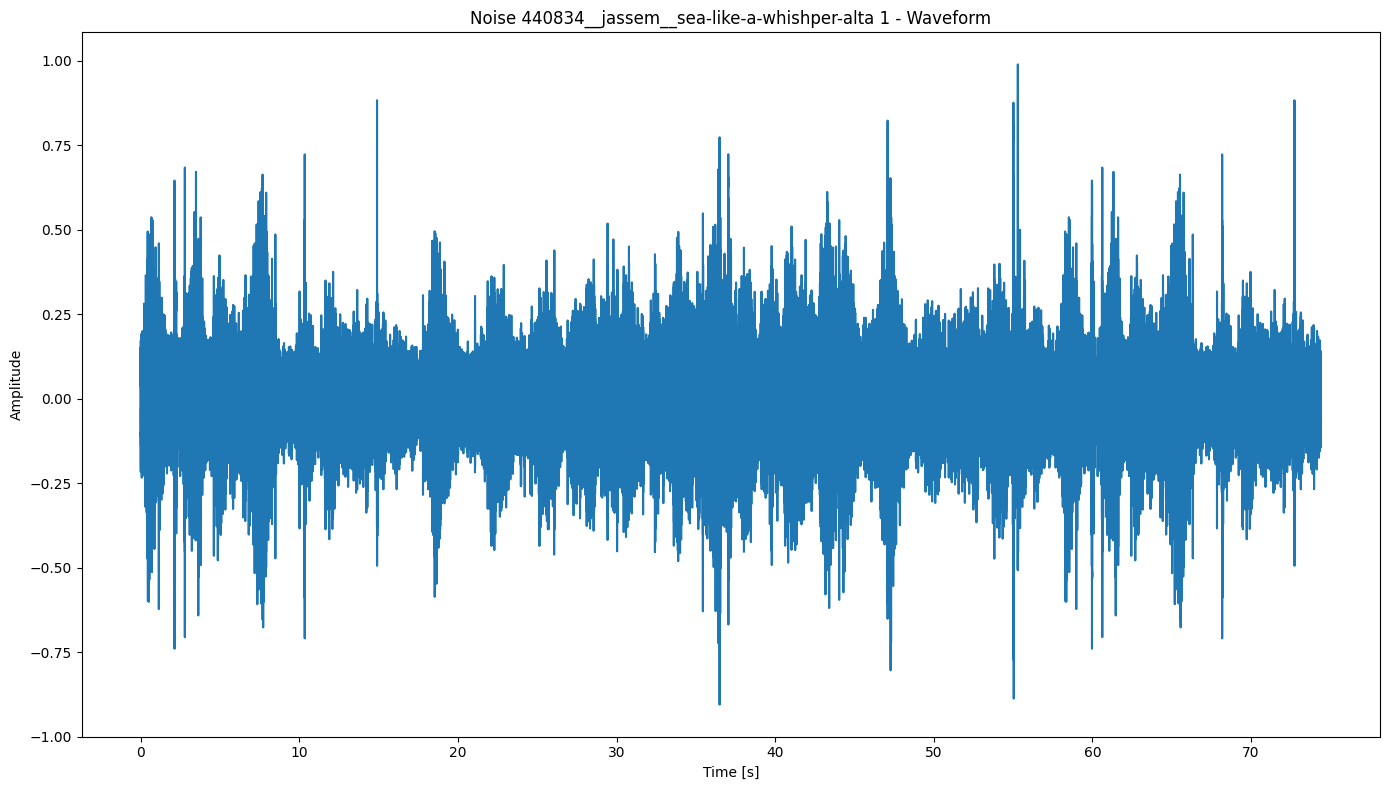

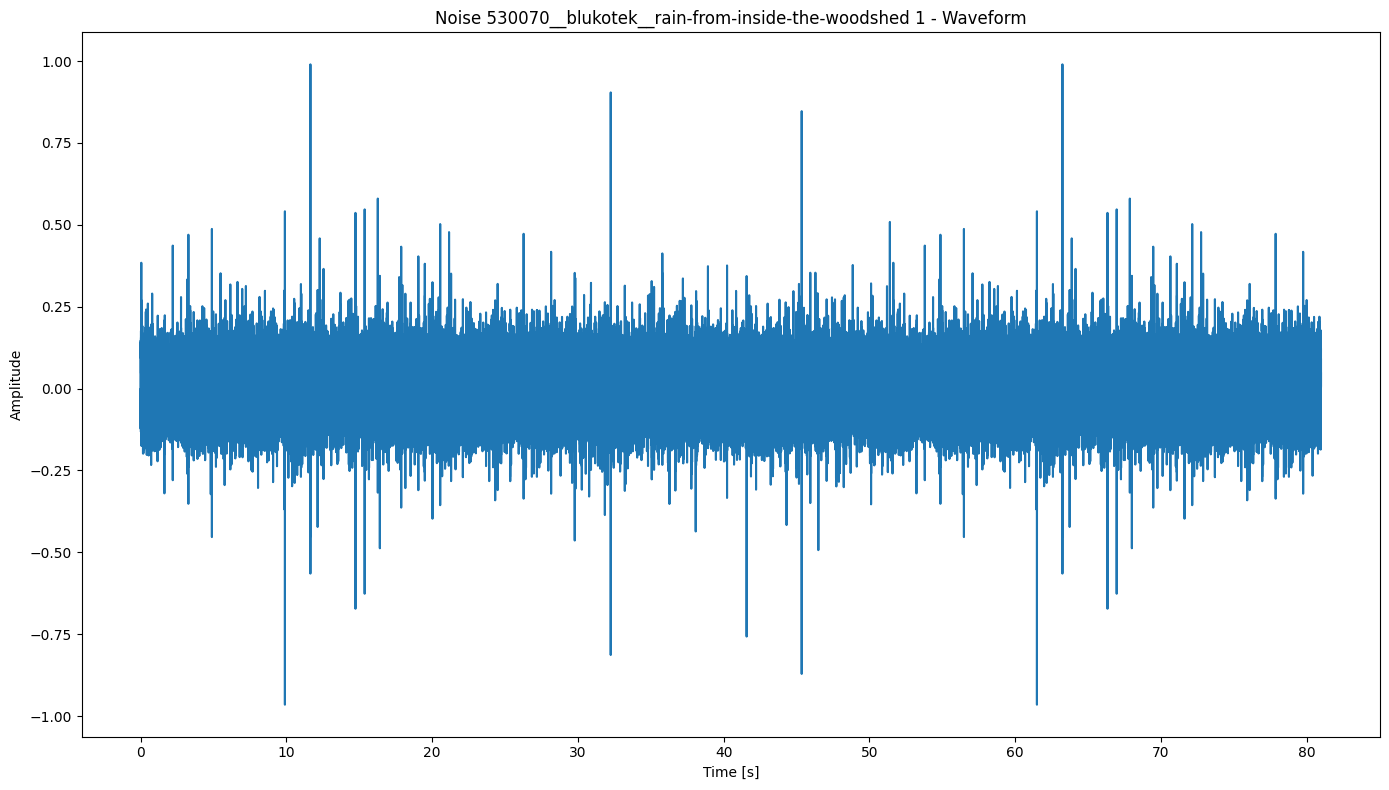

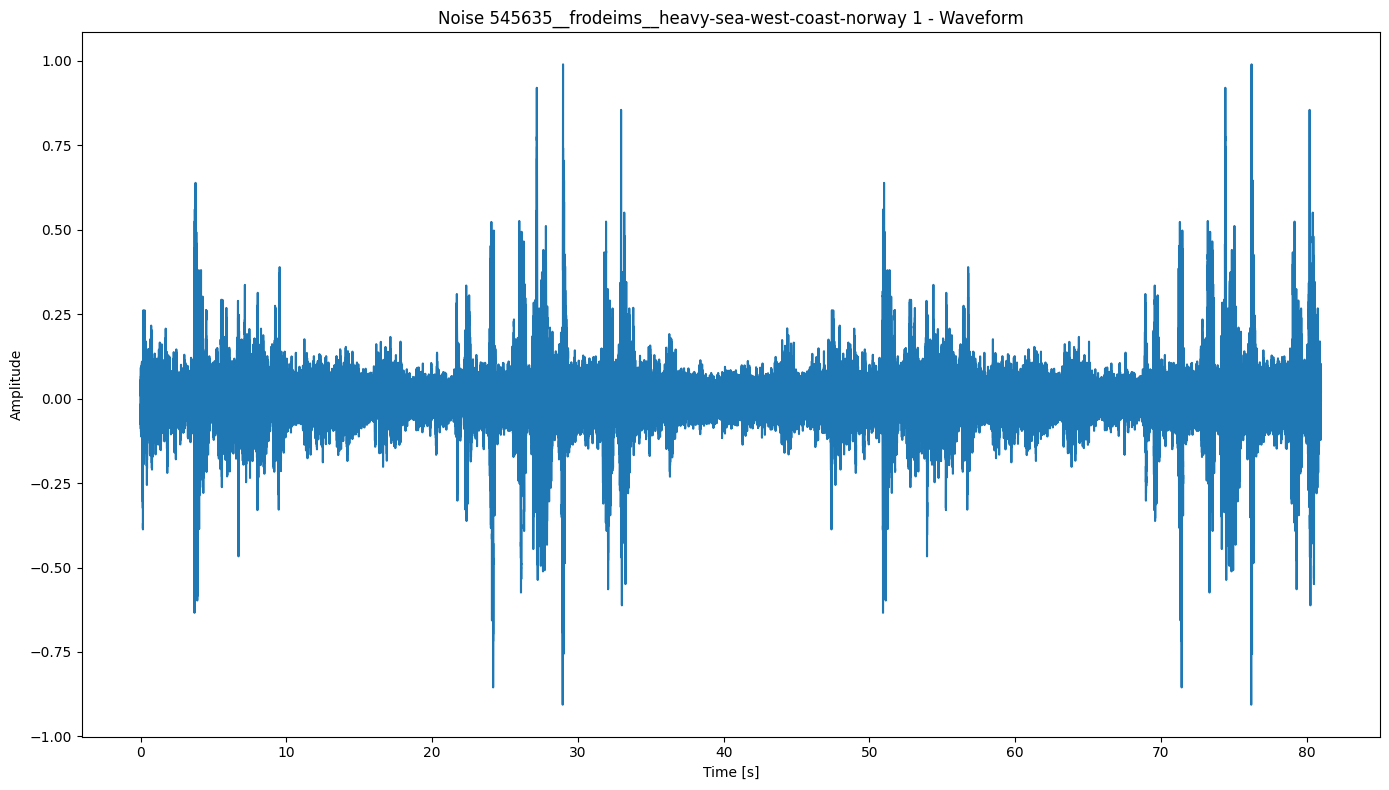

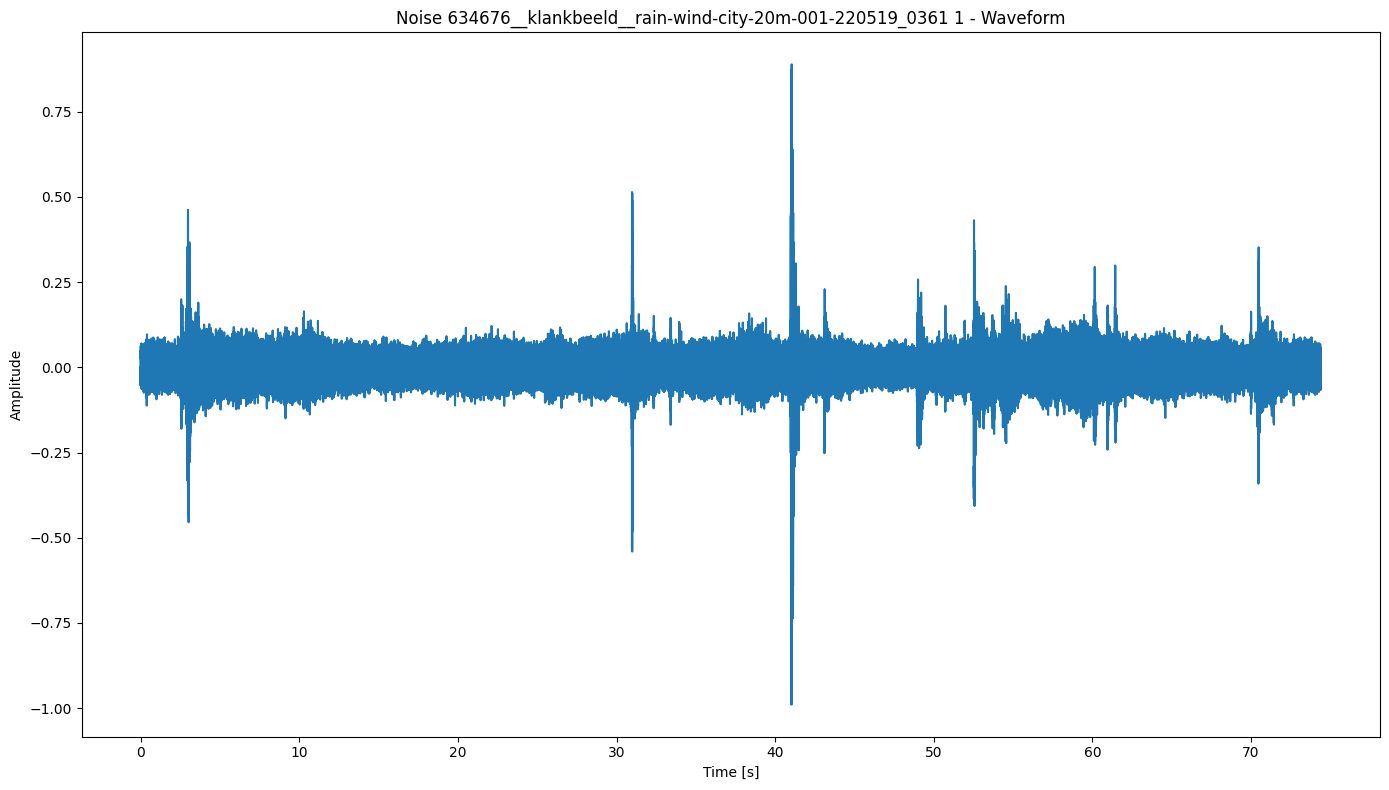

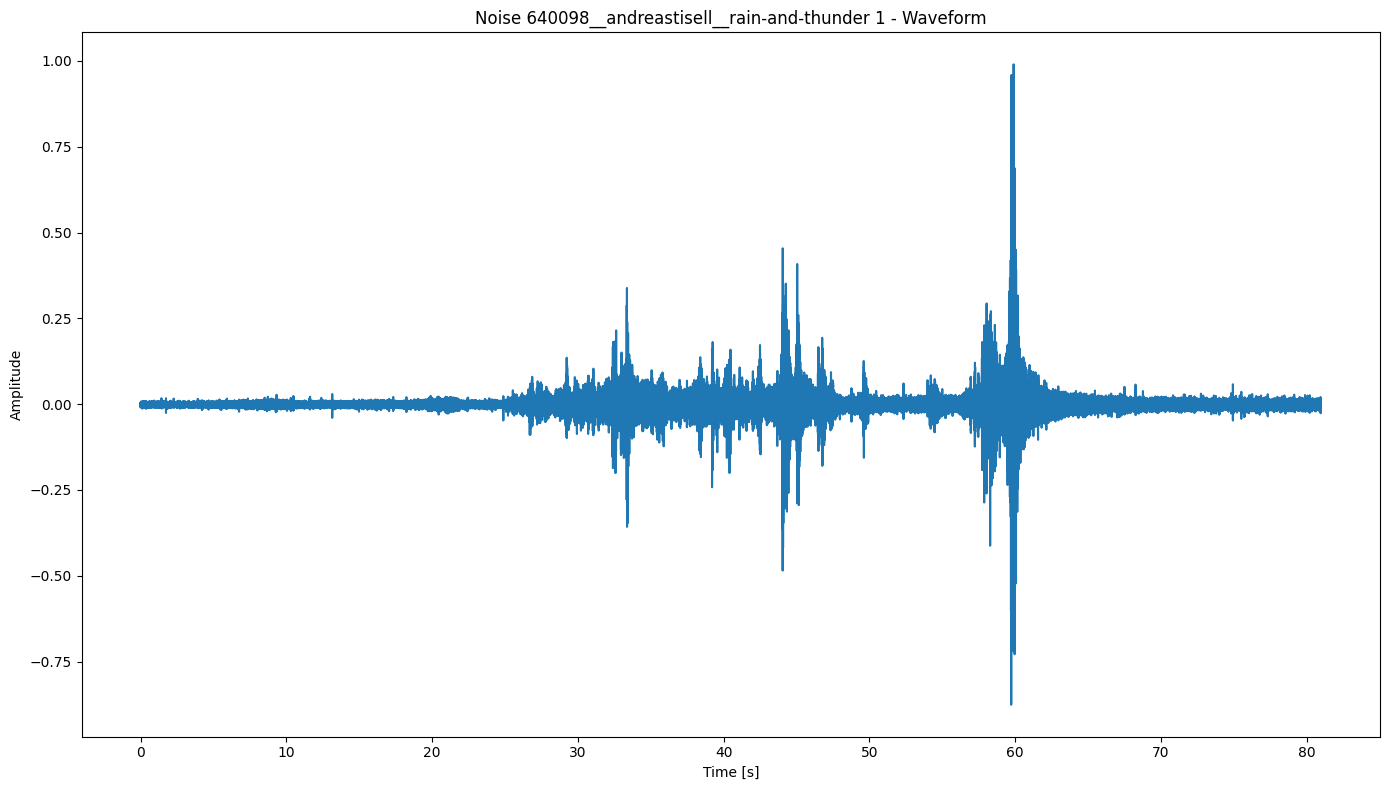

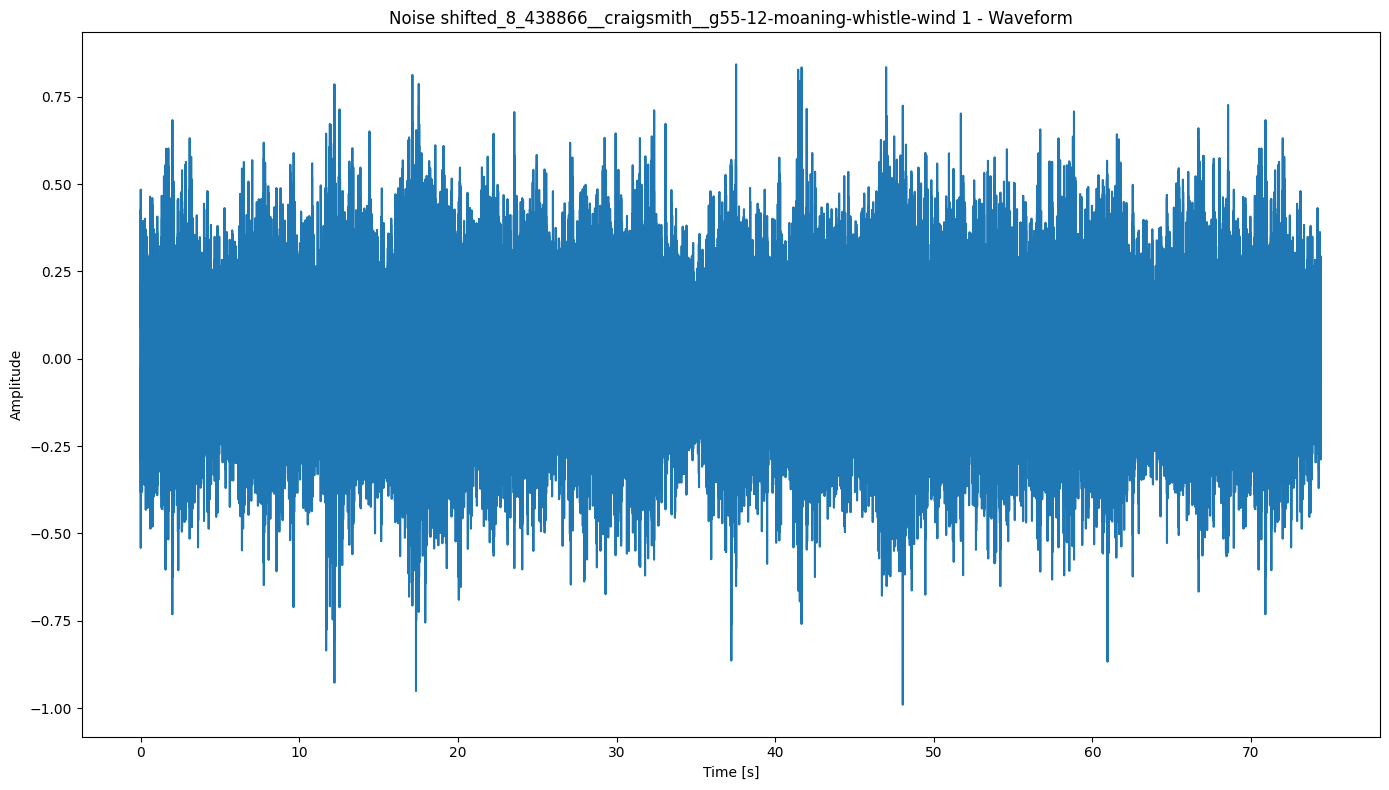

Loaded 9 noise files.


In [14]:
# Define load original audio and preprocess

folder = "dataset/"
aircraft_folder = Path(folder + "Gardemoen/clips")
noise_folder = Path(folder + "noise")
snr = 5 # Sjekk om 2 og -0,5 gir samme resultat
aircraft_vars = {}
noise_vars = {}
signal = []
length_target = None
sr_target = None

for source_wav in sorted(aircraft_folder.glob("*.wav")):
    signal, sr = load_mono(source_wav)

    if sr_target is None:
        sr_target = sr
    else:
        signal = librosa.resample(signal, orig_sr=sr, target_sr=sr_target)

    if length_target is None:
        length_target = len(signal)
    else:
        signal = set_length(signal, length_target)

    s_norm = normalize_peak(signal)
    plot_waveforms(s_norm[:, None], sr_target, f"Aircraft audio {source_wav.stem}")
    aircraft_vars[source_wav.stem] = (s_norm, sr_target)

print(f"Loaded {len(aircraft_vars)} aircraft files.")

for noise_wav in sorted(noise_folder.glob("*.wav")):
    signal, sr_target = load_mono(noise_wav, offset=2.5) #duration=31
    cut = sr_target * 3
    signal = signal[:-cut] # Remove last 3 seconds of noise to speach interference

    if sr_target is None:
        sr_target = sr
    else:
        signal = librosa.resample(signal, orig_sr=sr, target_sr=sr_target)

    if length_target is None:
        length_target = len(signal)
    else:
        signal = set_length(signal, length_target)

    s_norm = normalize_peak(signal)
    plot_waveforms(s_norm[:, None], sr_target, f"Noise {noise_wav.stem}")
    noise_vars[noise_wav.stem] = (s_norm, sr_target)

print(f"Loaded {len(noise_vars)} noise files.")

In [16]:
# Analyse frequency bands

for key, tup in aircraft_vars.items():
    signal, sr_target = tup
    res2 = most_powerful_band(signal, sr_target)  # signals shape (2, 1488000)
    print("\n")
    print(f"{key}.wav: \n Best band:", res2["best_band_per_channel"][0], "Peak freq:", res2["peak_freq_per_channel"][0] )

for key, tup in noise_vars.items():
    signal, sr_target = tup
    res2 = most_powerful_band(signal, sr_target)  # signals shape (2, 1488000)
    print("\n")
    print(f"{key}.wav: \n Best band:", res2["best_band_per_channel"][0], "Peak freq:", res2["peak_freq_per_channel"][0])



A2-0002_OPT_G_002_0001_Tr2.wav: 
 Best band: (167.79706860217857, 340.95926336153053) Peak freq: 281.25


213077__crosbychris__3-jan-2014-waves-breaking-over-sea-wall-at-crosby-during-high-spring-tide-in-winter-storm-with-applied-eq.wav: 
 Best band: (40.639477936279484, 82.57835834666739) Peak freq: 93.75


378150__magnus589__strong-wind.wav: 
 Best band: (20.0, 40.639477936279484) Peak freq: 11.71875


438866__craigsmith__g55-12-moaning-whistle-wind.wav: 
 Best band: (82.57835834666739, 167.79706860217857) Peak freq: 117.1875


440834__jassem__sea-like-a-whishper-alta.wav: 
 Best band: (167.79706860217857, 340.95926336153053) Peak freq: 246.09375


530070__blukotek__rain-from-inside-the-woodshed.wav: 
 Best band: (40.296549070699896, 81.19059335036619) Peak freq: 53.8330078125


545635__frodeims__heavy-sea-west-coast-norway.wav: 
 Best band: (20.0, 40.296549070699896) Peak freq: 10.7666015625


634676__klankbeeld__rain-wind-city-20m-001-220519_0361.wav: 
 Best band: (20.0, 40.63947



640098__andreastisell__rain-and-thunder: 
 Best band: (40.296549070699896, 81.19059335036619) Peak freq: 96.8994140625


dataset/noise/shifted_15_640098__andreastisell__rain-and-thunder.wav: 
 Best band: (163.58503645111347, 329.5956224292262) Peak freq: 226.0986328125
Shifted wind source saved to dataset/noise/shifted_15_640098__andreastisell__rain-and-thunder.wav with +15 semitones.


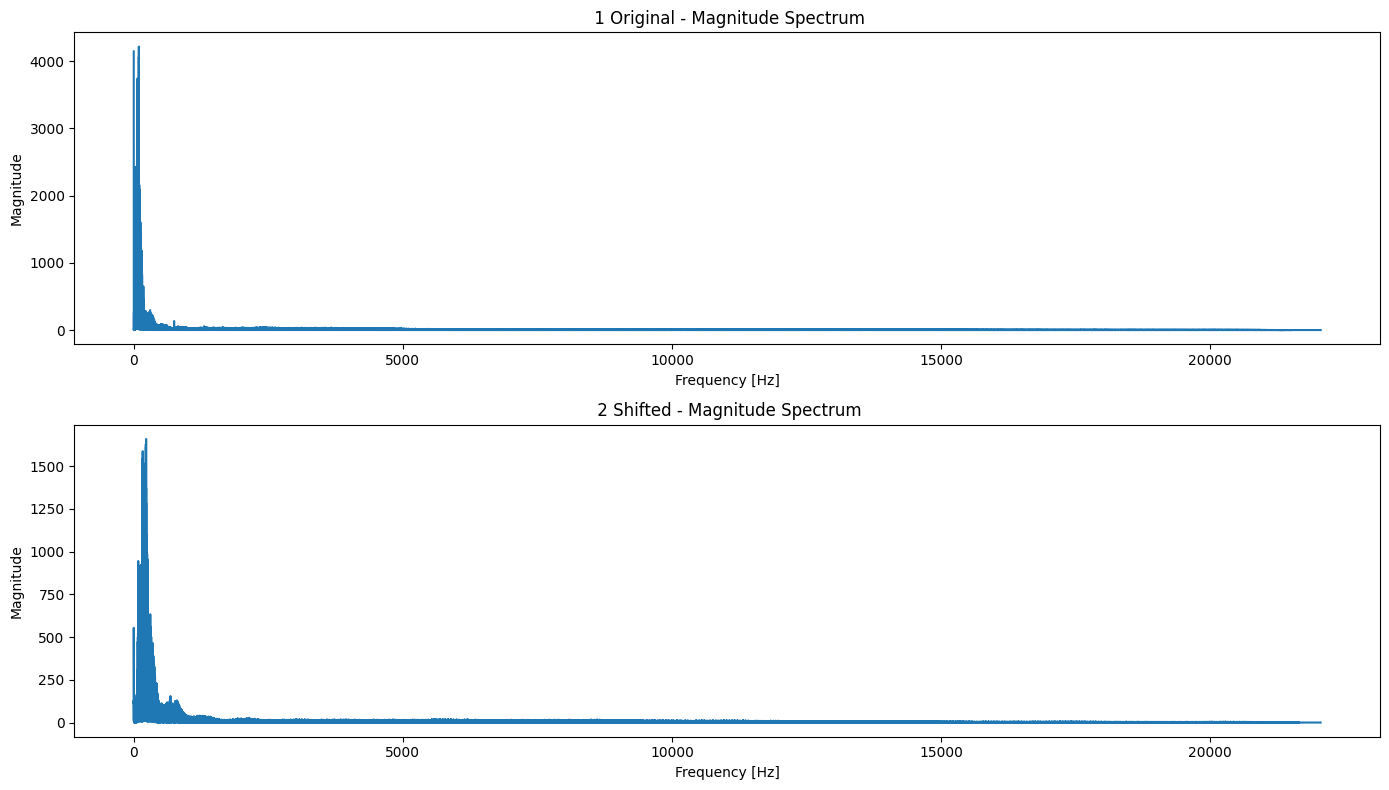

In [10]:
# Shift the frequencies of noise similar to the aircraft sources

wav_name = "640098__andreastisell__rain-and-thunder"
s2, sr2 = noise_vars[wav_name]     # original wind

res2 = most_powerful_band(s2, sr2)  # signals shape (2, 1488000)
print("\n")
print(f"{wav_name}: \n Best band:", res2["best_band_per_channel"][0], "Peak freq:", res2["peak_freq_per_channel"][0] )

n_steps = 15
s2_shifted = librosa.effects.pitch_shift(y=s2, sr=sr2, n_steps=n_steps)
new_wav_name = f'shifted_{n_steps}_{wav_name}'
save_to_path = f'dataset/noise/{new_wav_name}.wav'
sf.write(save_to_path, s2_shifted, sr2)

res2 = most_powerful_band(s2_shifted, sr2)  # signals shape (2, 1488000)
print("\n")
print(f"{save_to_path}: \n Best band:", res2["best_band_per_channel"][0], "Peak freq:", res2["peak_freq_per_channel"][0] )

print(f'Shifted wind source saved to {save_to_path} with +{n_steps} semitones.')

s2_array = np.vstack([s2[np.newaxis, :], s2_shifted[np.newaxis, :]])
titles = ["Original", "Shifted"]
plot_fft(s2_array.transpose(), sr2, "", titles=titles)

In [3]:
# Switch signal with shifted version

#del noise_vars[wav_name]
noise_vars[new_wav_name] = (s2_shifted, sr2)  # Update noise_vars with shifted signal

print(f'Current noise signals used:')
for key in noise_vars.keys():
    print(f'{key} \n')

NameError: name 's2_shifted' is not defined

In [ ]:
# Make parameters for mixing

s= []
w= []

for key, tup in aircraft_vars.items():
    signal, sr_target = tup
    s.append(signal)
    s.append(signal)
    s.append(signal)
    s.append(signal)
    s.append(signal)

for key, tup in noise_vars.items():
    signal, sr_target = tup
    w.append(signal)


In [ ]:
# Generate synthetic mixtures for Part 1
importlib.reload(gt_conv)

snrs = [10, 5, 3, 2, 1]  # SNR values for mixtures
paths_all = {}
out_dir="dataset/synthetic_data/part1"

for snr in snrs:
    theta1s = np.full(5, snr, dtype=float)  # [snr., snr., snr., snr., snr.]
    theta2s = np.ones(5, dtype=float)   
    A=np.column_stack([theta1s, theta2s])

    X, paths = mix_signals(
        s=s, 
        w=w,
        sr=sr_target, 
        A= A,                  
        out_dir=out_dir,
        snr=snr
    )
    
    paths_all[snr] = paths

print(f"Mixtures created and saved in {out_dir}.")

# Make gt file for synthetic mixtures Part 1
for snr, new_files in paths_all.items():
    gt_conv.duplicate_gt_for_filenames(
        in_path="dataset/Gardemoen/gt_A2-0002_OPT_G_002_0001_Tr2.csv",
        out_path= f"dataset/synthetic_data/snr{snr}_gt_A2-0002_OPT_G_002_0001_Tr2" + ".csv",
        new_filenames=new_files, 
        include_original=False,
        drop_dupes=False, 
        out_sep="\t"
    )
    

Mixtures created and saved in dataset/synthetic_data/part1.
Wrote duplicated GT to: dataset/synthetic_data/snr10_gt_A2-0002_OPT_G_002_0001_Tr2.csv
Wrote duplicated GT to: dataset/synthetic_data/snr5_gt_A2-0002_OPT_G_002_0001_Tr2.csv
Wrote duplicated GT to: dataset/synthetic_data/snr3_gt_A2-0002_OPT_G_002_0001_Tr2.csv
Wrote duplicated GT to: dataset/synthetic_data/snr2_gt_A2-0002_OPT_G_002_0001_Tr2.csv
Wrote duplicated GT to: dataset/synthetic_data/snr1_gt_A2-0002_OPT_G_002_0001_Tr2.csv


In [ ]:
# Generate complementing synthetic mixtures for Part 2
importlib.reload(gt_conv)

snrs = [10, 5, 3, 2, 1]  # SNR values for mixtures
out_dir="dataset/synthetic_data/"
paths_all = {}

for snr in snrs:
    theta1s = np.full(5, snr, dtype=float)  # [snr., snr., snr., snr., snr.]
    theta2s = np.ones(5, dtype=float)   
    A=np.column_stack([theta1s, theta2s])

    X2, paths2 = mix_signals(
    s=s, 
    w=w,
    sr=sr_target, 
    A= A,                   # or supply your own 5x2
    out_dir=out_dir,
    )
    
    paths_all[snr] = paths2

# Make gt file for synthetic mixtures Part 2
for snr, new_files in paths_all.items():
    gt_conv.duplicate_gt_for_filenames(
        in_path="dataset/Gardemoen/gt_A2-0002_OPT_G_002_0001_Tr2.csv",
        out_path= f"dataset/synthetic_data/snr{snr}_gt_A2-0002_OPT_G_002_0001_Tr2" + ".csv",
        new_filenames=new_files, 
        include_original=False,
        drop_dupes=False, 
        out_sep="\t"
    )

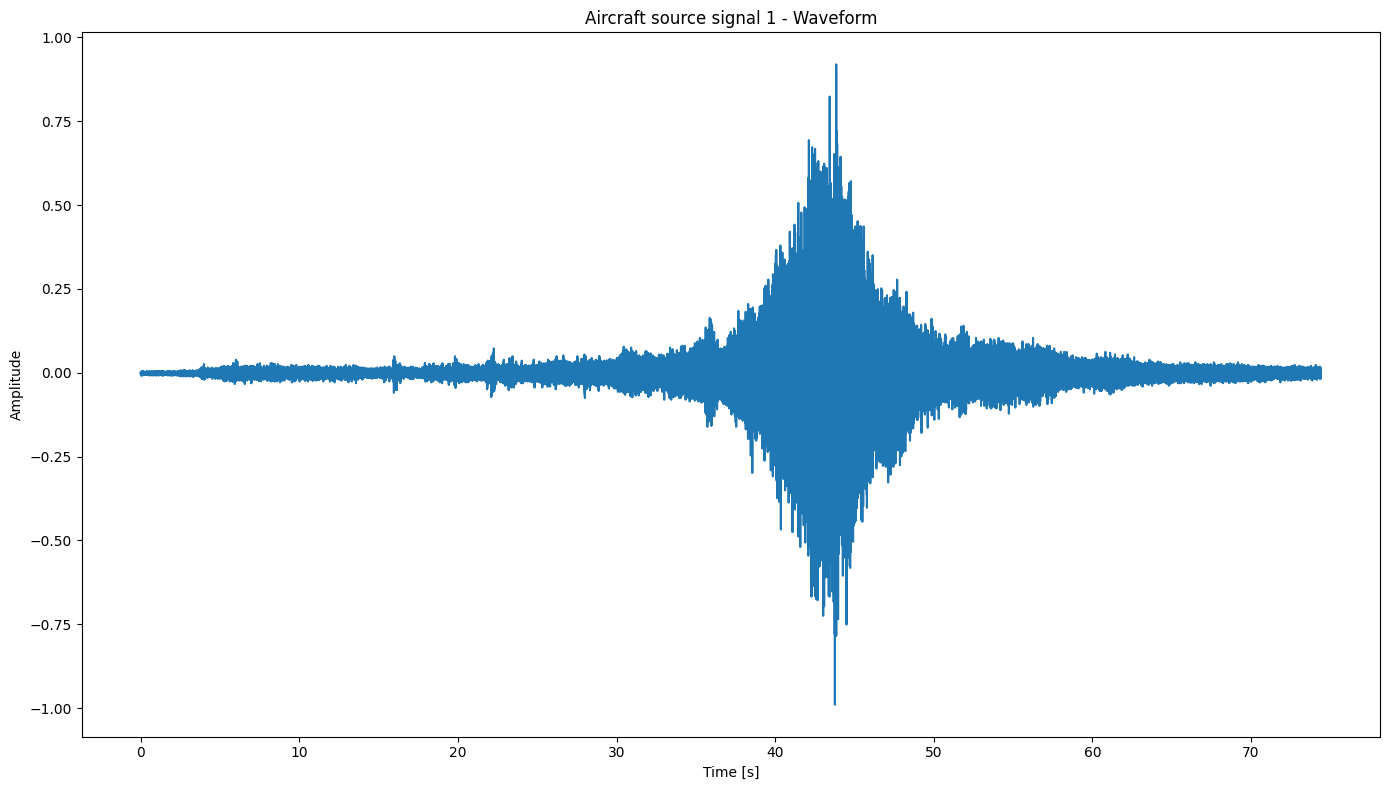

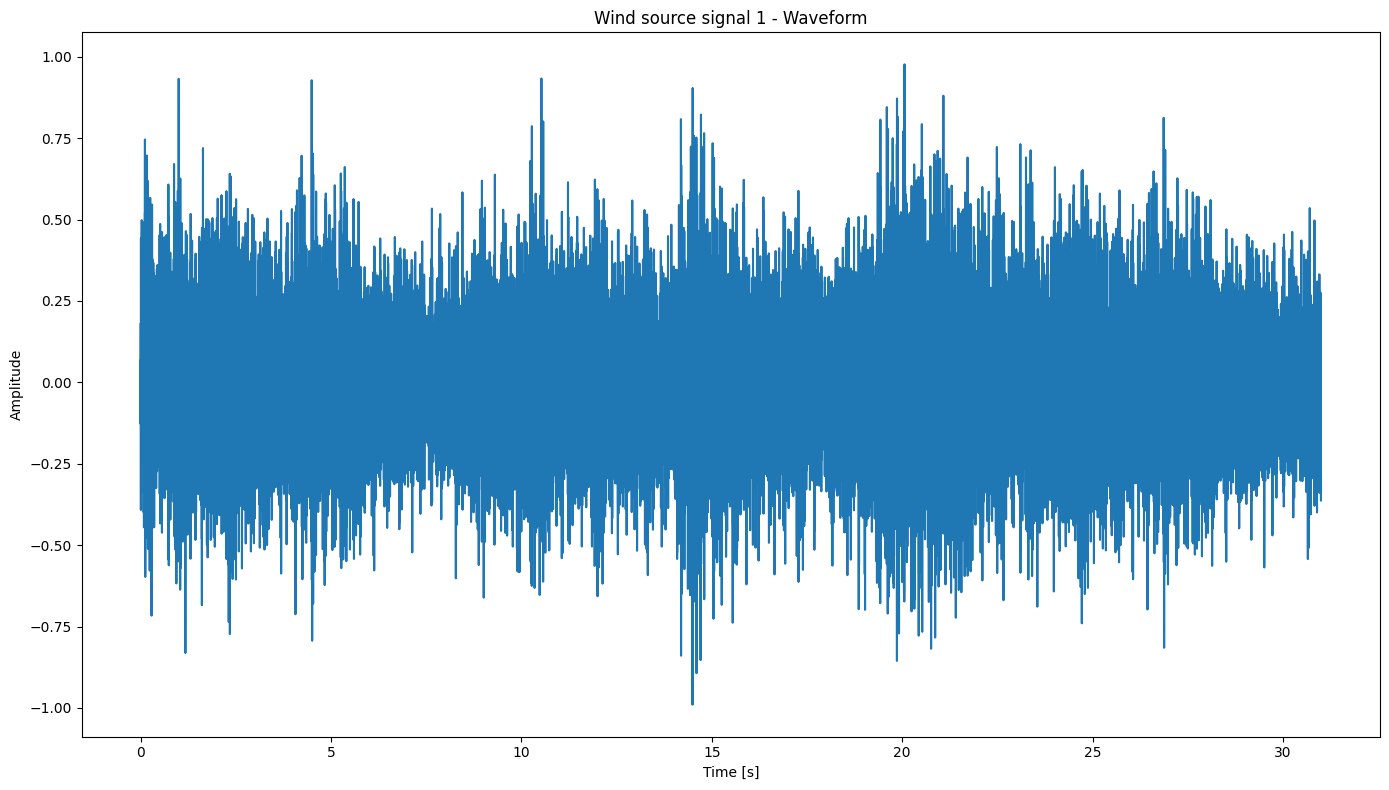

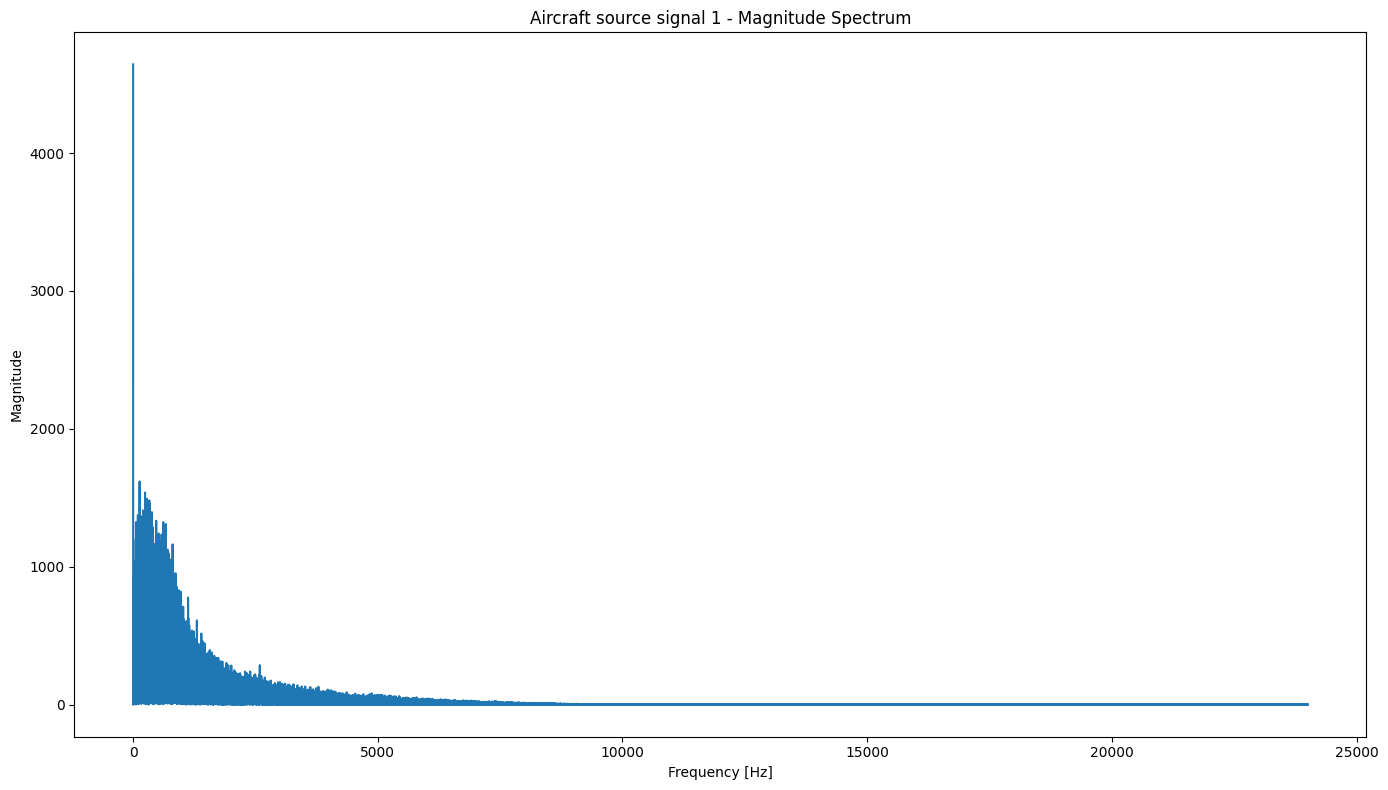

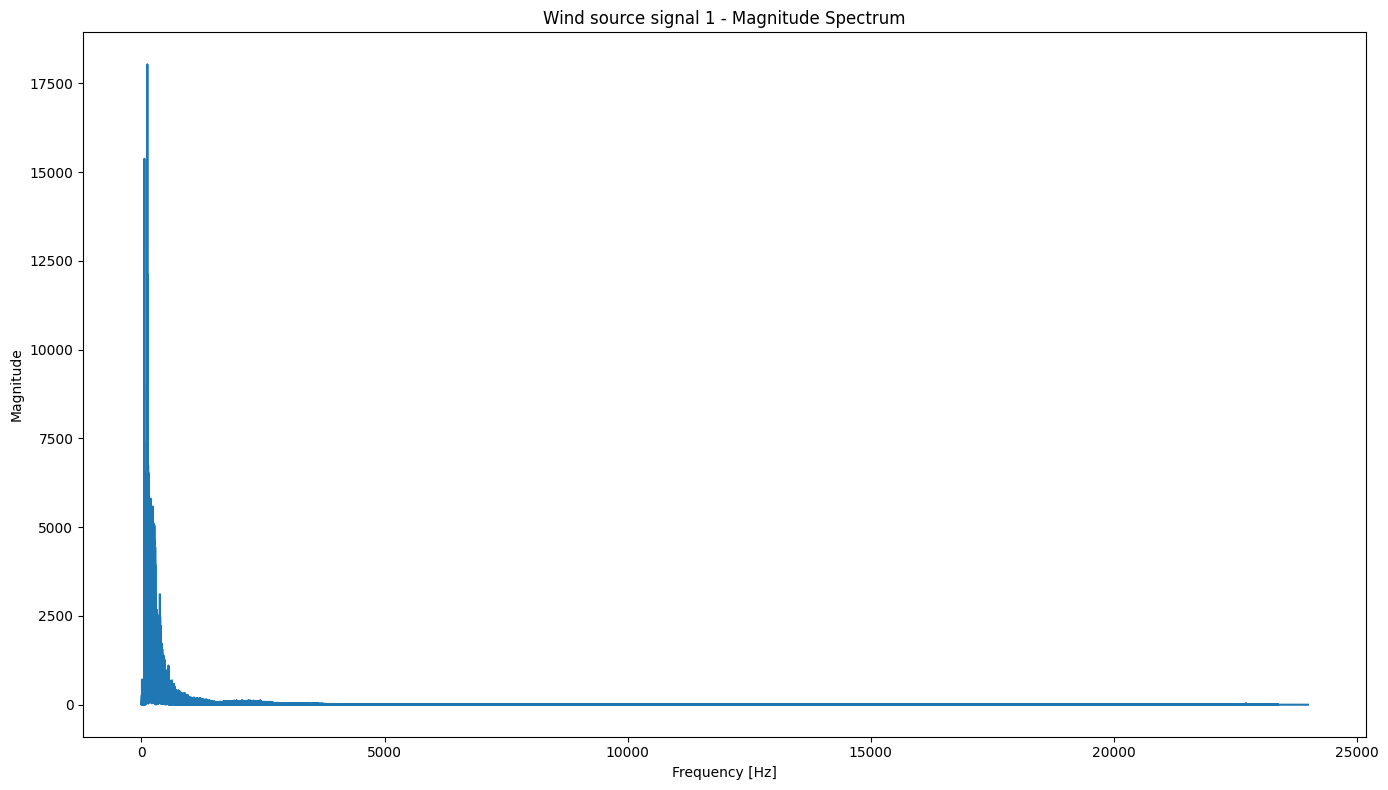

In [ ]:
# Plot source signals

plot_waveforms(s1.reshape(-1,1), sr1, "Aircraft source signal")
plot_waveforms(s2.reshape(-1,1), sr2, "Wind source signal")

plot_fft(s1.reshape(-1,1), sr1, "Aircraft source signal")
plot_fft(s2.reshape(-1,1), sr1, "Wind source signal")

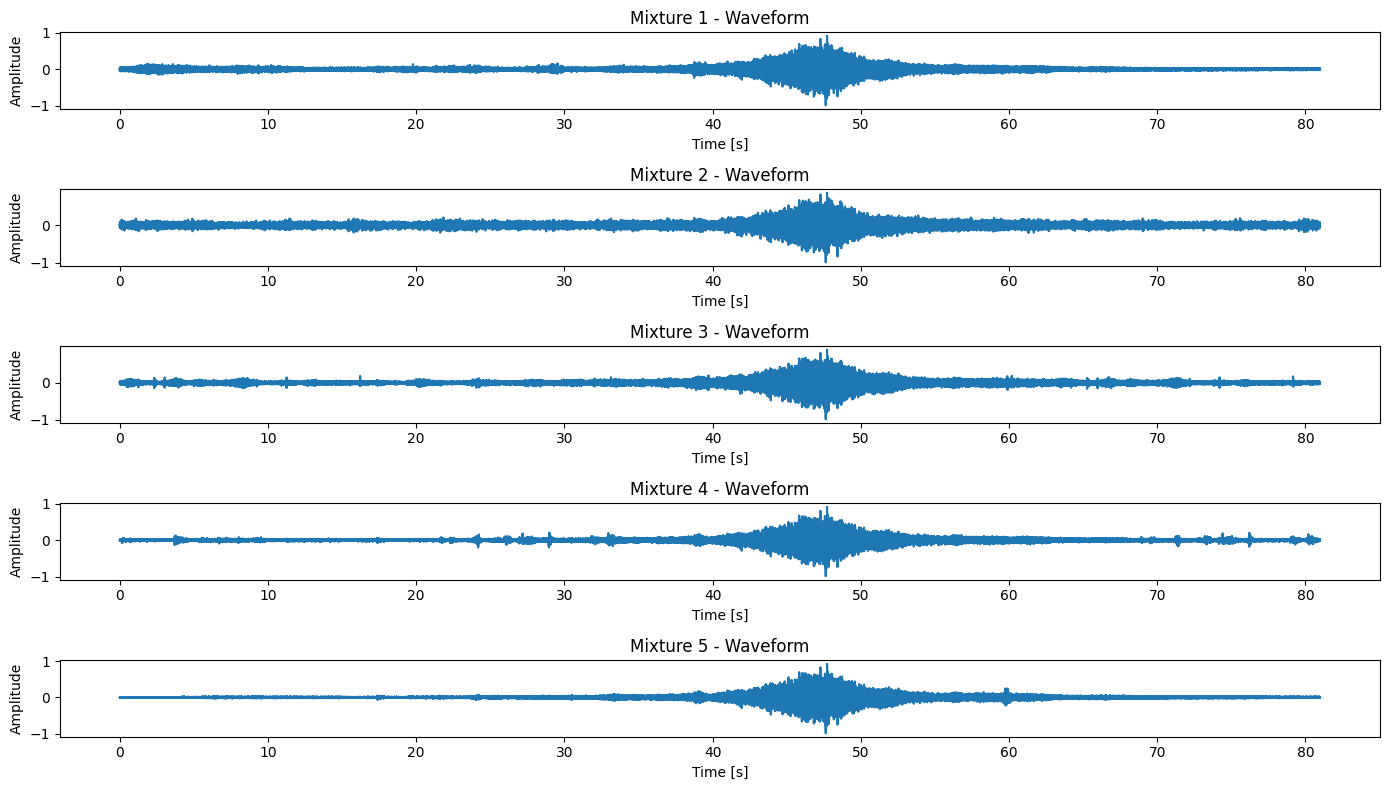

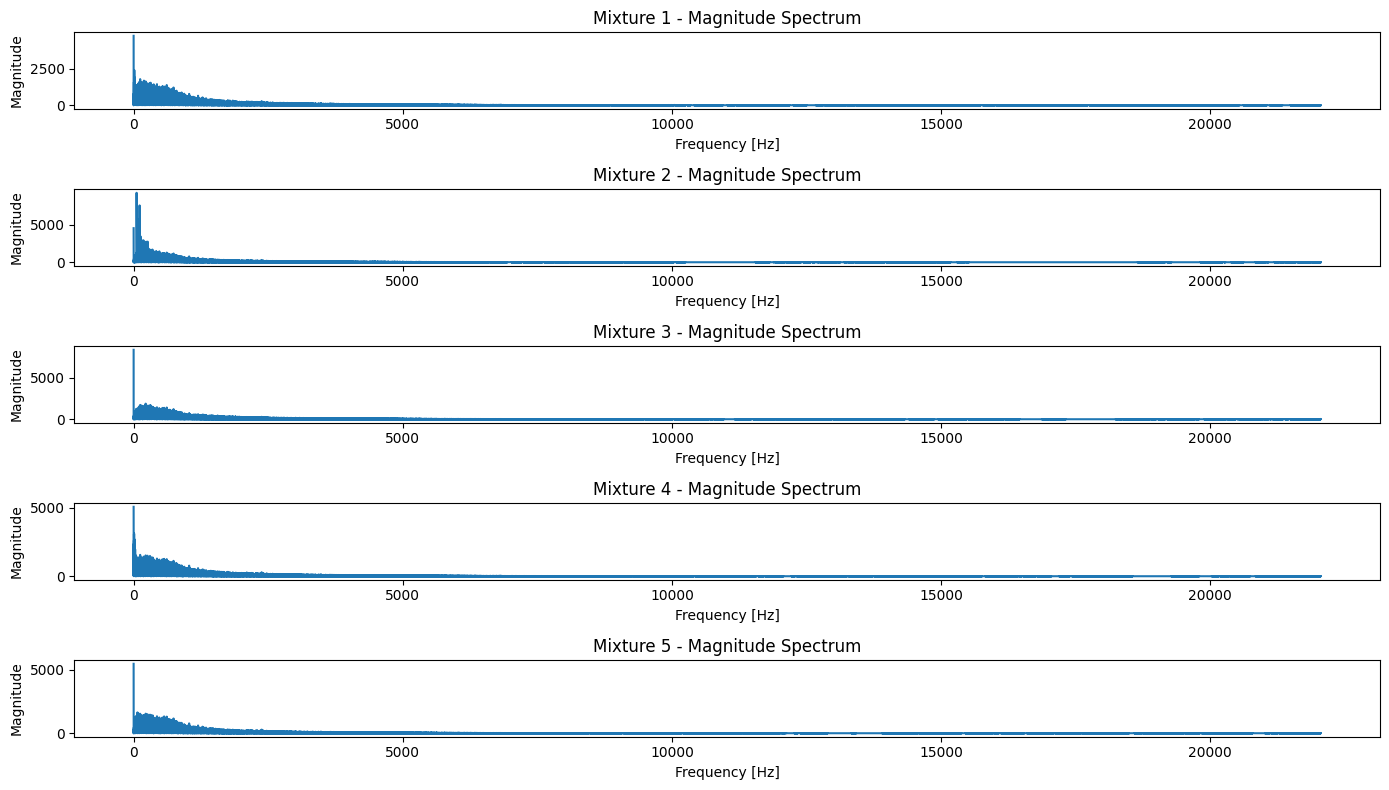

In [175]:
# Plot mixed signals

plot_waveforms(X.transpose(), sr_target, "Mixture")
plot_fft(X.transpose(), sr_target, "Mixture")